In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt

print("OSMnx", ox.__version__)

# Pull the drivable road network for Wellington City
place = "Wellington City, Wellington, New Zealand"
G = ox.graph_from_place(place, network_type="drive")

print("Network pulled")
print("Nodes (intersections):", len(G.nodes))
print("Edges (road segments):", len(G.edges))

OSMnx 2.1.0
Network pulled
Nodes (intersections): 4445
Edges (road segments): 9850


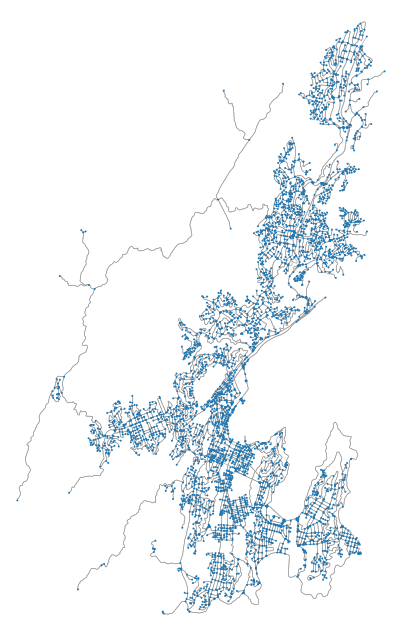

In [2]:
fig, ax = ox.plot_graph(
    G,
    node_size=2,
    node_color="#1f78b4",
    edge_color="#999999",
    edge_linewidth=0.4,
    bgcolor="white"
)

In [3]:
# Save the network so we don't re-download
ox.save_graphml(G, "../data/processed/wellington_network.graphml")
print("Saved.")

# Look at road types — criticality analysis will focus on major routes
edges = ox.graph_to_gdfs(G, nodes=False)
print("\nRoad types (highway tag):")
print(edges["highway"].value_counts().head(12))

Saved.

Road types (highway tag):
highway
residential                     6022
tertiary                        1380
secondary                       1247
unclassified                     583
living_street                    164
trunk                            111
primary                          105
motorway_link                     43
trunk_link                        41
motorway                          34
secondary_link                    28
[living_street, residential]      28
Name: count, dtype: int64


In [4]:
# Load the NZ SA2 boundaries
sa2_path = "../data/raw/statistical-area-2-2023-clipped-generalised.shp"
sa2 = gpd.read_file(sa2_path)

print("Total SA2 areas (all NZ):", len(sa2))
print("CRS:", sa2.crs)
print("\nColumns:")
print(sa2.columns.tolist())
print("\nFirst few rows:")
print(sa2.drop(columns="geometry").head())

Total SA2 areas (all NZ): 2310
CRS: EPSG:2193

Columns:
['SA22023_V1', 'SA22023__1', 'SA22023__2', 'LAND_AREA_', 'AREA_SQ_KM', 'Shape_Leng', 'geometry']

First few rows:
  SA22023_V1          SA22023__1          SA22023__2  LAND_AREA_  AREA_SQ_KM  \
0     100100          North Cape          North Cape  829.188012  829.188012   
1     100200    Rangaunu Harbour    Rangaunu Harbour  274.004295  274.004295   
2     100400  Karikari Peninsula  Karikari Peninsula  174.440751  174.440751   
3     100500            Tangonge            Tangonge  177.182117  177.182117   
4     100900           Rangitihi           Rangitihi   84.539982   84.539982   

      Shape_Leng  
0  416039.151064  
1  149089.110095  
2  140149.099270  
3  101466.900183  
4   60636.302194  


Wellington-area SA2s: 88

Sample names:
['Mākara-Ohariu', 'Karori Park', 'Karori East', 'Mount Cook East', 'Mount Victoria South', 'Newtown South', 'Melrose', 'Rānui Heights', 'Porirua Central', 'Tawa North', 'Linden', 'Tawa South', 'Tawa Central', 'Grenada North', 'Churton Park North', 'Glenside-Churton Park East', 'Johnsonville West', 'Takapu-Horokiwi', 'Churton Park South', 'Karori West']


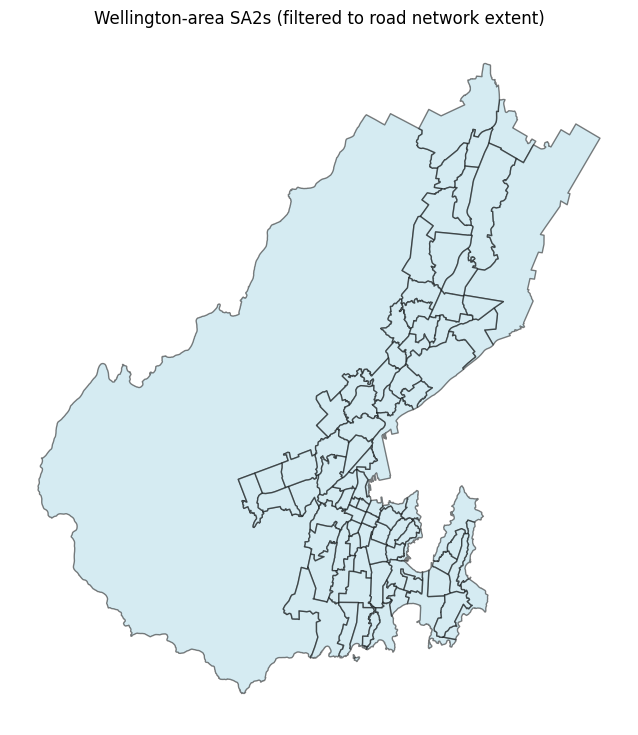

In [5]:
# The SA2 file has no region column, so filter spatially to our Wellington road network.
# Get the bounding box of the road network (it's Wellington City).
nodes_gdf = ox.graph_to_gdfs(G, edges=False)  # network nodes, in WGS84 (EPSG:4326)
net_bounds = nodes_gdf.total_bounds  # [minx, miny, maxx, maxy] in lon/lat

from shapely.geometry import box
net_box = gpd.GeoDataFrame(geometry=[box(*net_bounds)], crs="EPSG:4326")

# Reproject the SA2 layer to WGS84 to match, then keep SA2s intersecting the network area
sa2_wgs = sa2.to_crs("EPSG:4326")
wgtn_sa2 = gpd.sjoin(sa2_wgs, net_box, how="inner", predicate="intersects").drop(columns="index_right")

print("Wellington-area SA2s:", len(wgtn_sa2))
print("\nSample names:")
print(wgtn_sa2["SA22023__1"].head(20).tolist())

# Quick plot to sanity-check
fig, ax = plt.subplots(figsize=(9, 9))
wgtn_sa2.plot(ax=ax, edgecolor="black", facecolor="lightblue", alpha=0.5)
ax.set_title("Wellington-area SA2s (filtered to road network extent)")
ax.set_axis_off()
plt.show()

In [6]:
# Load the census population-by-SA2 layer
pop = gpd.read_file("../data/raw/sa2_population.geojson")

print("Rows:", len(pop))
print("CRS:", pop.crs)
print("\nColumns:")
print(pop.columns.tolist())
print("\nFirst few rows (no geometry):")
print(pop.drop(columns="geometry").head())

Rows: 2395
CRS: EPSG:4326

Columns:
['OBJECTID', 'SA22023_V1_00', 'SA22023_V1_00_NAME', 'SA22023_V1_00_NAME_ASCII', 'VAR_1_1', 'VAR_1_2', 'VAR_1_3', 'VAR_1_4', 'VAR_1_5', 'AREA_SQ_KM', 'LAND_AREA_SQ_KM', 'geometry']

First few rows (no geometry):
   OBJECTID SA22023_V1_00         SA22023_V1_00_NAME  \
0         1        363700   Oceanic Southland Region   
1         2        258200   Oceanic Northland Region   
2         3        363400  Oceanic West Coast Region   
3         4        342900    Oceanic Chatham Islands   
4         5        357000                  Fiordland   

    SA22023_V1_00_NAME_ASCII  VAR_1_1  VAR_1_2  VAR_1_3  VAR_1_4  VAR_1_5  \
0   Oceanic Southland Region        0        3        0   -998.0   -100.0   
1   Oceanic Northland Region        0        3        3   -998.0      0.0   
2  Oceanic West Coast Region        0        0        6   -998.0   -998.0   
3    Oceanic Chatham Islands        0        0        0   -998.0   -998.0   
4                  Fiordland   

In [7]:
# The VAR_1_x columns are cryptic. Let's verify which is 2023 population.
# Sanity check: sum each VAR column across all NZ and compare to known totals.
# NZ 2023 census usually-resident population = 4,993,923.
for col in ["VAR_1_1", "VAR_1_2", "VAR_1_3"]:
    # exclude the -998 / -100 suppression flags
    valid = pop[pop[col] > 0][col]
    print(f"{col}: sum = {valid.sum():,.0f}")

VAR_1_1: sum = 4,241,958
VAR_1_2: sum = 4,699,731
VAR_1_3: sum = 4,993,920


In [8]:
# Keep only what we need; rename the cryptic column to something readable
pop_clean = pop[["SA22023_V1_00", "SA22023_V1_00_NAME", "VAR_1_3", "geometry"]].copy()
pop_clean = pop_clean.rename(columns={
    "SA22023_V1_00": "sa2_code",
    "SA22023_V1_00_NAME": "sa2_name",
    "VAR_1_3": "population_2023"
})

# Handle suppression flags (-998, -100 etc. mean "confidential/no data") -> set to 0
pop_clean.loc[pop_clean["population_2023"] < 0, "population_2023"] = 0

# Filter to the Wellington SA2s we identified earlier (by matching the names in wgtn_sa2)
wgtn_names = set(wgtn_sa2["SA22023__1"])
wgtn_pop = pop_clean[pop_clean["sa2_name"].isin(wgtn_names)].copy()

print("Wellington SA2s with population:", len(wgtn_pop))
print("Total Wellington-area population:", f"{wgtn_pop['population_2023'].sum():,.0f}")
print("\nLargest few by population:")
print(wgtn_pop.nlargest(8, "population_2023")[["sa2_name", "population_2023"]].to_string(index=False))

Wellington SA2s with population: 88
Total Wellington-area population: 205,035

Largest few by population:
                    sa2_name  population_2023
          Churton Park North             4383
Strathmore (Wellington City)             3744
                   Wadestown             3696
                  Berhampore             3693
             Island Bay East             3594
               Newtown South             3588
                  Aro Valley             3582
           Johnsonville West             3471


In [9]:
# Assign each SA2's population to its nearest network node.
# Use SA2 centroids as the population "source points".
import numpy as np

# Reproject Wellington population to NZ metric CRS (EPSG:2193) for accurate centroids
wgtn_pop_m = wgtn_pop.to_crs("EPSG:2193")
wgtn_pop_m["centroid"] = wgtn_pop_m.geometry.centroid

# Project the road graph to the same metric CRS
G_proj = ox.project_graph(G, to_crs="EPSG:2193")

# For each SA2, find the nearest network node and assign its population there
node_population = {}  # node_id -> total population assigned
for _, row in wgtn_pop_m.iterrows():
    c = row["centroid"]
    nearest = ox.distance.nearest_nodes(G_proj, X=c.x, Y=c.y)
    node_population[nearest] = node_population.get(nearest, 0) + row["population_2023"]

print("SA2s assigned to nodes:", len(wgtn_pop_m))
print("Distinct network nodes carrying population:", len(node_population))
print("Total population assigned:", f"{sum(node_population.values()):,.0f}")

SA2s assigned to nodes: 88
Distinct network nodes carrying population: 88
Total population assigned: 205,035


In [10]:
import networkx as nx

# --- Destination: Wellington CBD / hospital area ---
# Wellington Regional Hospital (Newtown) is the key emergency destination: -41.308, 174.780
# Use the CBD instead if you prefer; hospital is the more emergency-relevant target.
dest_pt = gpd.GeoSeries([gpd.points_from_xy([174.780], [-41.308])[0]], crs="EPSG:4326").to_crs("EPSG:2193").iloc[0]
destination = ox.distance.nearest_nodes(G_proj, X=dest_pt.x, Y=dest_pt.y)
print("Destination node (Wellington Hospital):", destination)

# --- Baseline: how many people can reach the hospital normally? ---
pop_nodes = list(node_population.keys())
und = G_proj.to_undirected()

def reachable_population(graph):
    """Total population sitting on nodes that can still reach the destination."""
    # nodes connected to destination in this (possibly damaged) graph
    comp = nx.node_connected_component(graph, destination)
    return sum(node_population.get(n, 0) for n in pop_nodes if n in comp)

baseline = reachable_population(und)
print(f"Population that can reach the hospital normally: {baseline:,.0f} of {sum(node_population.values()):,.0f}")

# --- Identify major links to test (arterials only, not residential) ---
edges_proj = ox.graph_to_gdfs(G_proj, nodes=False).reset_index()
major_types = ["motorway", "trunk", "primary", "secondary",
               "motorway_link", "trunk_link", "primary_link", "secondary_link"]
def is_major(hw):
    if isinstance(hw, list):
        return any(h in major_types for h in hw)
    return hw in major_types
major_edges = edges_proj[edges_proj["highway"].apply(is_major)]
print(f"\nMajor links to test: {len(major_edges)} (of {len(edges_proj)} total)")

Destination node (Wellington Hospital): 288070314
Population that can reach the hospital normally: 205,035 of 205,035

Major links to test: 1628 (of 9850 total)


In [13]:
import networkx as nx
import pandas as pd

# Use the directed projected graph with edge lengths for travel-distance routing
G_dir = G_proj

# --- Baseline: each population node's normal shortest-path distance to the hospital ---
# Compute distance FROM hospital to all nodes (undirected distance is symmetric enough here)
base_dist = nx.single_source_dijkstra_path_length(G_proj.to_undirected(), destination, weight="length")

# Population-weighted baseline travel distance (only nodes that can reach the hospital)
pop_nodes = list(node_population.keys())
def weighted_distance(dist_map):
    """Sum of population x distance-to-hospital. Unreachable nodes get a big penalty."""
    total = 0
    PENALTY = 100000  # 100km penalty for being fully cut off
    for n in pop_nodes:
        d = dist_map.get(n, PENALTY)
        total += node_population[n] * d
    return total

baseline_cost = weighted_distance(base_dist)
print(f"Baseline population-weighted travel cost: {baseline_cost:,.0f} person-metres")

# --- Criticality: for each major link, how much does total travel cost rise if it fails? ---
und = G_proj.to_undirected()
results = []

for _, edge in major_edges.iterrows():
    u, v = edge["u"], edge["v"]
    if not und.has_edge(u, v):
        continue
    edge_data = dict(und.get_edge_data(u, v))
    und.remove_edge(u, v)

    # Recompute distances to hospital with this link gone
    new_dist = nx.single_source_dijkstra_path_length(und, destination, weight="length")
    new_cost = weighted_distance(new_dist)
    extra_cost = new_cost - baseline_cost  # person-metres of added travel

    for key, data in edge_data.items():
        und.add_edge(u, v, key=key, **data)

    if extra_cost > 0:
        results.append({
            "u": u, "v": v,
            "road_name": edge["name"] if ("name" in edge and edge["name"] is not None) else "(unnamed)",
            "highway": edge["highway"],
            "added_person_km": extra_cost / 1000  # convert to person-km
        })

crit = pd.DataFrame(results).sort_values("added_person_km", ascending=False).reset_index(drop=True)
print(f"\nMajor links that increase travel cost when failed: {len(crit)} of {len(major_edges)}")
print("\nTop 15 most critical links (by added travel burden across the population):")
print(crit.head(15)[["road_name", "highway", "added_person_km"]].round(0).to_string(index=False))

Baseline population-weighted travel cost: 1,517,087,532 person-metres

Major links that increase travel cost when failed: 695 of 1628

Top 15 most critical links (by added travel burden across the population):
                                                road_name   highway  added_person_km
                            Johnsonville Porirua Motorway  motorway         107788.0
Te Ara Nui o Te Rangihaeata / Transmission Gully Motorway  motorway         107788.0
                                                Main Road secondary          43127.0
                                                Main Road secondary          43127.0
                                            Adelaide Road secondary          35120.0
                                            Adelaide Road secondary          35120.0
                                            Adelaide Road secondary          35120.0
                                            Adelaide Road secondary          35120.0
                         

In [15]:
# Some road_name / highway values are lists (multi-tagged OSM segments).
# Convert them to strings so we can group.
crit_clean = crit.copy()
crit_clean["road_name"] = crit_clean["road_name"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else x
)
crit_clean["highway"] = crit_clean["highway"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

# Aggregate criticality by road name (OSMnx splits roads into many segments)
crit_by_road = (crit_clean[crit_clean["road_name"] != "(unnamed)"]
                .groupby("road_name")
                .agg(total_added_person_km=("added_person_km", "sum"),
                     segments=("added_person_km", "size"),
                     highway=("highway", "first"))
                .sort_values("total_added_person_km", ascending=False)
                .reset_index())

print("Top 12 most critical ROADS (aggregated across their segments):")
print(crit_by_road.head(12)[["road_name", "highway", "segments", "total_added_person_km"]].round(0).to_string(index=False))
print(f"\nTotal named roads with criticality: {len(crit_by_road)}")

Top 12 most critical ROADS (aggregated across their segments):
                                                road_name   highway  segments  total_added_person_km
                                            Adelaide Road secondary        54               560092.0
                                               Aro Street secondary        14               164890.0
                                                Hutt Road   primary        15               146084.0
                                                Main Road secondary        38               129517.0
                            Johnsonville Porirua Motorway  motorway        10               110444.0
Te Ara Nui o Te Rangihaeata / Transmission Gully Motorway  motorway         1               107788.0
                                            Newlands Road secondary        19                91824.0
                                              Karori Road secondary        46                66988.0
                            

In [16]:
import os
os.makedirs("../outputs", exist_ok=True)

# Save the road-level criticality ranking
crit_by_road.to_csv("../outputs/wellington_road_criticality.csv", index=False)
print("Saved ranking to outputs/wellington_road_criticality.csv")

# Build a per-segment criticality value for mapping (max burden each segment causes)
crit_clean["seg_key"] = list(zip(crit_clean["u"], crit_clean["v"]))
seg_burden = crit_clean.groupby("seg_key")["added_person_km"].max().to_dict()

# Attach burden to the edges GeoDataFrame
edges_map = ox.graph_to_gdfs(G_proj, nodes=False).reset_index()
edges_map["criticality"] = edges_map.apply(
    lambda r: seg_burden.get((r["u"], r["v"]), 0), axis=1
)

print("Edges with non-zero criticality:", (edges_map["criticality"] > 0).sum())
print("Max segment criticality:", round(edges_map["criticality"].max()))

Saved ranking to outputs/wellington_road_criticality.csv
Edges with non-zero criticality: 697
Max segment criticality: 107788


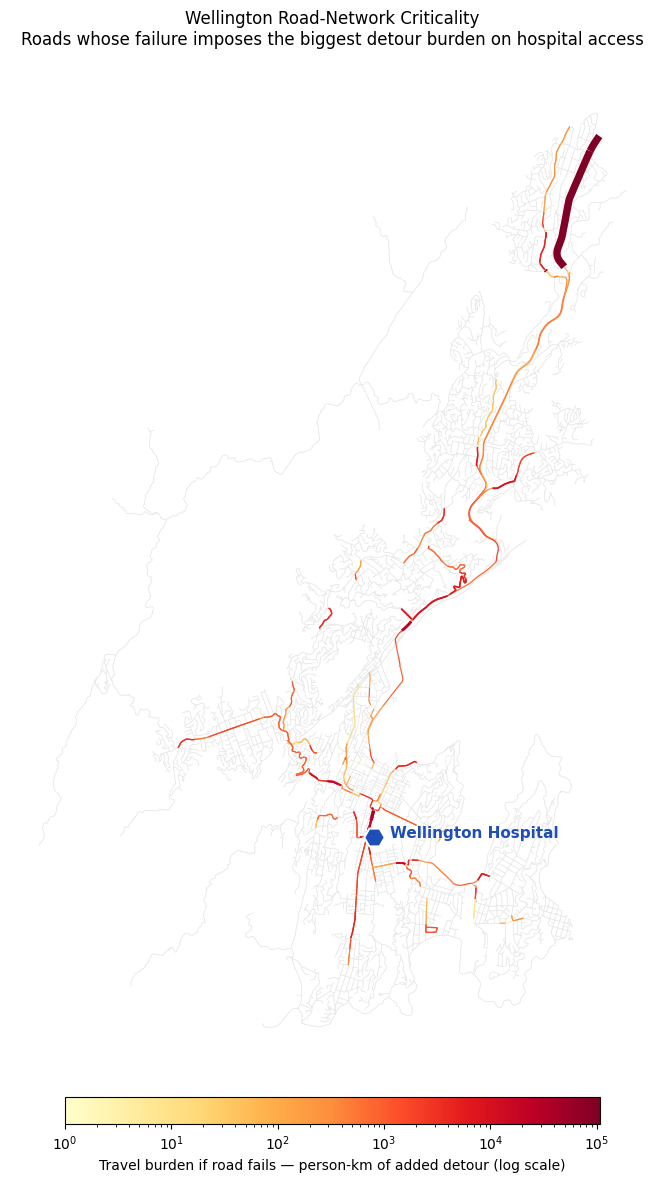

Map saved (log-scaled colors + colorbar).


In [19]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(11, 13))

# Base network in light grey
edges_map.plot(ax=ax, color="#e8e8e8", linewidth=0.4, zorder=1)

crit_segs = edges_map[edges_map["criticality"] > 0].copy()

# Log-scale the color so the gradient is visible (not dominated by the one huge value)
norm = mcolors.LogNorm(vmin=max(crit_segs["criticality"].min(), 1),
                       vmax=crit_segs["criticality"].max())
cmap = cm.YlOrRd

crit_segs.plot(
    ax=ax, column="criticality", cmap=cmap, norm=norm,
    linewidth=crit_segs["criticality"] / crit_segs["criticality"].max() * 4.5 + 0.8,
    zorder=2, legend=False
)

# Manual colorbar with the log norm
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.5, pad=0.02)
cbar.set_label("Travel burden if road fails — person-km of added detour (log scale)")

# Hospital marker
dest_node = ox.graph_to_gdfs(G_proj, edges=False).loc[destination]
ax.scatter(dest_node.geometry.x, dest_node.geometry.y, s=220, c="#1f4eb8",
           marker="H", edgecolors="white", linewidths=1.5, zorder=5)
ax.annotate("Wellington Hospital", (dest_node.geometry.x, dest_node.geometry.y),
            xytext=(12, 0), textcoords="offset points", fontsize=11,
            fontweight="bold", color="#1f4eb8", zorder=6)

ax.set_title("Wellington Road-Network Criticality\n"
             "Roads whose failure imposes the biggest detour burden on hospital access",
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/wellington_criticality_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved (log-scaled colors + colorbar).")

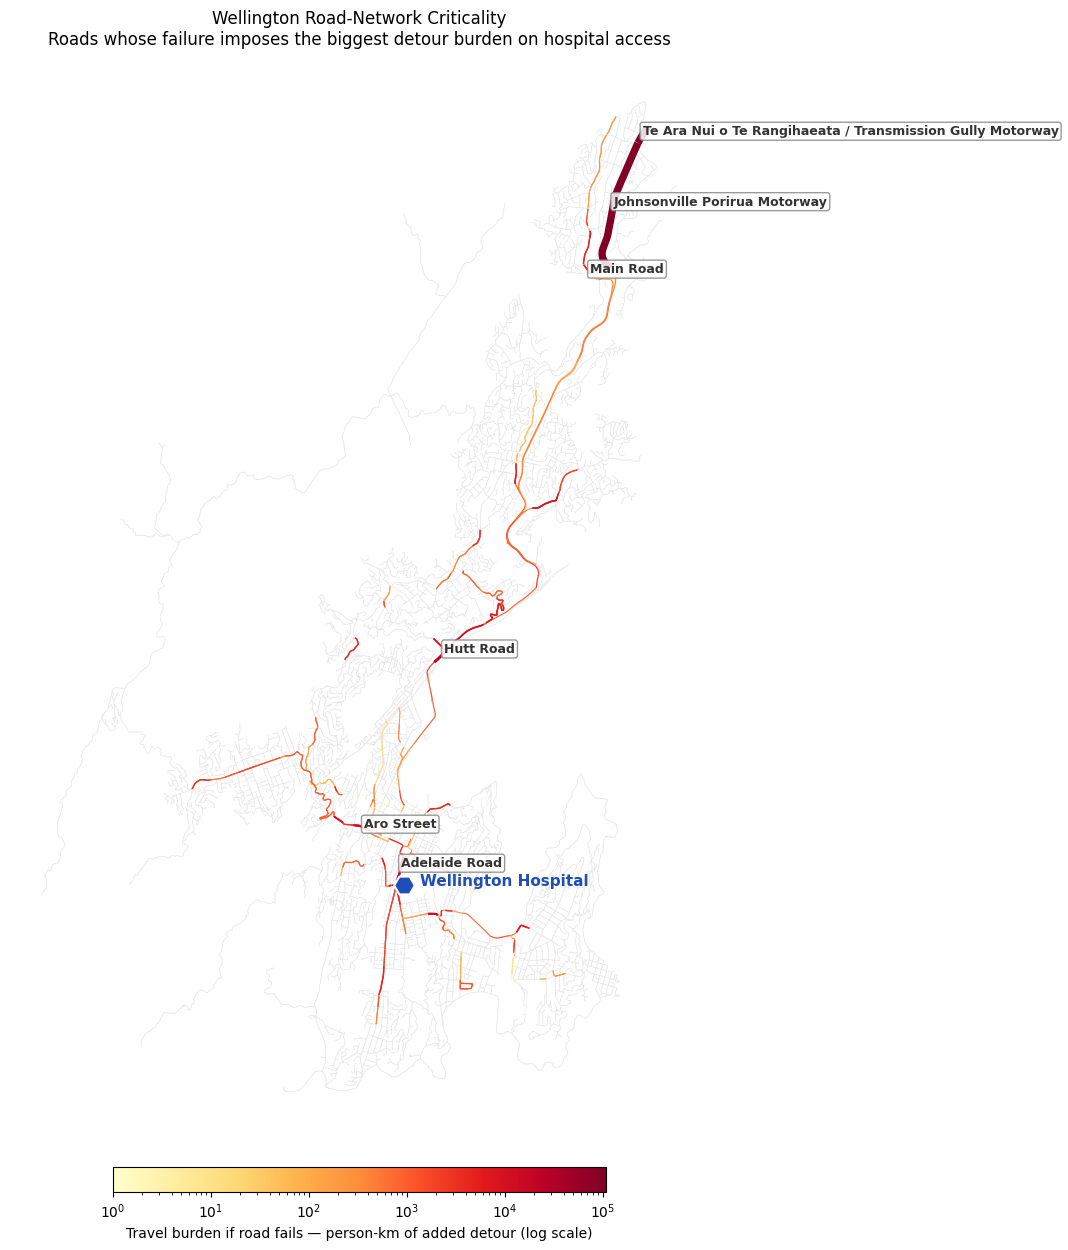

Map saved with road labels.


In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(12, 14))

# Base network in light grey
edges_map.plot(ax=ax, color="#e8e8e8", linewidth=0.4, zorder=1)

crit_segs = edges_map[edges_map["criticality"] > 0].copy()
norm = mcolors.LogNorm(vmin=max(crit_segs["criticality"].min(), 1),
                       vmax=crit_segs["criticality"].max())
cmap = cm.YlOrRd
crit_segs.plot(ax=ax, column="criticality", cmap=cmap, norm=norm,
               linewidth=crit_segs["criticality"] / crit_segs["criticality"].max() * 4.5 + 0.8,
               zorder=2, legend=False)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.5, pad=0.02)
cbar.set_label("Travel burden if road fails — person-km of added detour (log scale)")

# Hospital marker
dest_node = ox.graph_to_gdfs(G_proj, edges=False).loc[destination]
ax.scatter(dest_node.geometry.x, dest_node.geometry.y, s=220, c="#1f4eb8",
           marker="H", edgecolors="white", linewidths=1.5, zorder=6)
ax.annotate("Wellington Hospital", (dest_node.geometry.x, dest_node.geometry.y),
            xytext=(12, 0), textcoords="offset points", fontsize=11,
            fontweight="bold", color="#1f4eb8", zorder=7)

# --- Label the top critical roads ---
# For each of the top roads, find its highest-criticality segment and label there
top_roads = crit_by_road.head(6)["road_name"].tolist()
labeled = set()
# attach road name to edges_map for matching
def name_str(x):
    return ", ".join(x) if isinstance(x, list) else x
edges_map["name_str"] = edges_map["name"].apply(lambda x: name_str(x) if x is not None else "")

for road in top_roads:
    # segments of this road that have criticality
    segs = edges_map[(edges_map["name_str"] == road) & (edges_map["criticality"] > 0)]
    if len(segs) == 0:
        continue
    # pick the most critical segment, label at its midpoint
    top_seg = segs.loc[segs["criticality"].idxmax()]
    pt = top_seg.geometry.interpolate(0.5, normalized=True)
    ax.annotate(road, (pt.x, pt.y), fontsize=9, fontweight="bold",
                color="#333333", zorder=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#888", alpha=0.85))

ax.set_title("Wellington Road-Network Criticality\n"
             "Roads whose failure imposes the biggest detour burden on hospital access",
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/wellington_criticality_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved with road labels.")